In [1]:
import pandas as pd
import numpy as np
import sys
from contextlib import redirect_stdout

from ml_pipeline.subpopulation import run_pipeline, run_model_error_analysis
from ml_evaluation.error_analysis import comprehensive_error_analysis, analyze_feature_contribution_to_errors, create_error_visualization

import warnings
warnings.filterwarnings('ignore')

/home/valeriya/project/homeserve/credit_policy/.direnv/python-3.12.0/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (7.2.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
# FILTER TO STOVE OWNERS
print("\n🎯 FILTERING TO STOVE OWNERS")
print("="*80)

# Load data
df_quotes = pd.read_csv('cleaned_quote_data.csv')
df_quotes['dt_creation_devis'] = pd.to_datetime(df_quotes['dt_creation_devis'])

# Get customers with stove
has_stove = df_quotes.groupby('numero_compte')['famille_equipement_produit'].apply(
    lambda x: 'Poêle' in x.values
)

stove_owner_ids = has_stove[has_stove].index.tolist()

# Filter data
df_quotes_stove = df_quotes[df_quotes['numero_compte'].isin(stove_owner_ids)].copy()

print(f"Original customers: {df_quotes['numero_compte'].nunique():,}")
print(f"Stove owners: {len(stove_owner_ids):,}")
print(f"Quotes: {len(df_quotes_stove):,}")

# Save to file
df_quotes_stove.to_csv('cleaned_quote_data_stove.csv', index=False)
print(f"\n✅ Saved to cleaned_quote_data_stove.csv")


🎯 FILTERING TO STOVE OWNERS
Original customers: 25,716
Stove owners: 6,301
Quotes: 9,023

✅ Saved to cleaned_quote_data_stove.csv


In [3]:
df_quotes = pd.read_csv('cleaned_quote_data_stove.csv')


📊 Original quote data: 9,023 quotes from 6,301 customers

🏗️  BUILDING FEATURES FOR SUBPOPULATION CUSTOMERS
Creating OPTIMIZED customer features (mode: first_conversion)...
  Filtering post-first-purchase data...
  Customers: 6,301, Quotes: 8,752
  Calculating features...
  Calculating price trajectory (optimized)...
✓ Created 14 leakage-free features
→ 6,301 customers | 41.5% converters
⏱️  Execution time: 2.6 seconds
✅ SUCCESS! Achieved ≤ 3s target
CREATING FIRST CONVERSION PREDICTION FEATURES (LEAKAGE-FREE)
  Total customers: 6,301
⚡ Processing customers with corrected first-conversion logic...
  Processed 0/6,301 customers
  Processed 5,000/6,301 customers
✅ First-conversion features calculation complete

🔍 VALIDATION REPORT:
   Total customers: 6,301
   First converters: 2,613 (41.5%)
   Never converters: 3,688

📊 Distribution check:
   Converters with 0 historical quotes: 2,199
   Non-converters with 0 historical quotes: 2,709
   Avg historical quotes - Converters: 0.2
   Avg hi

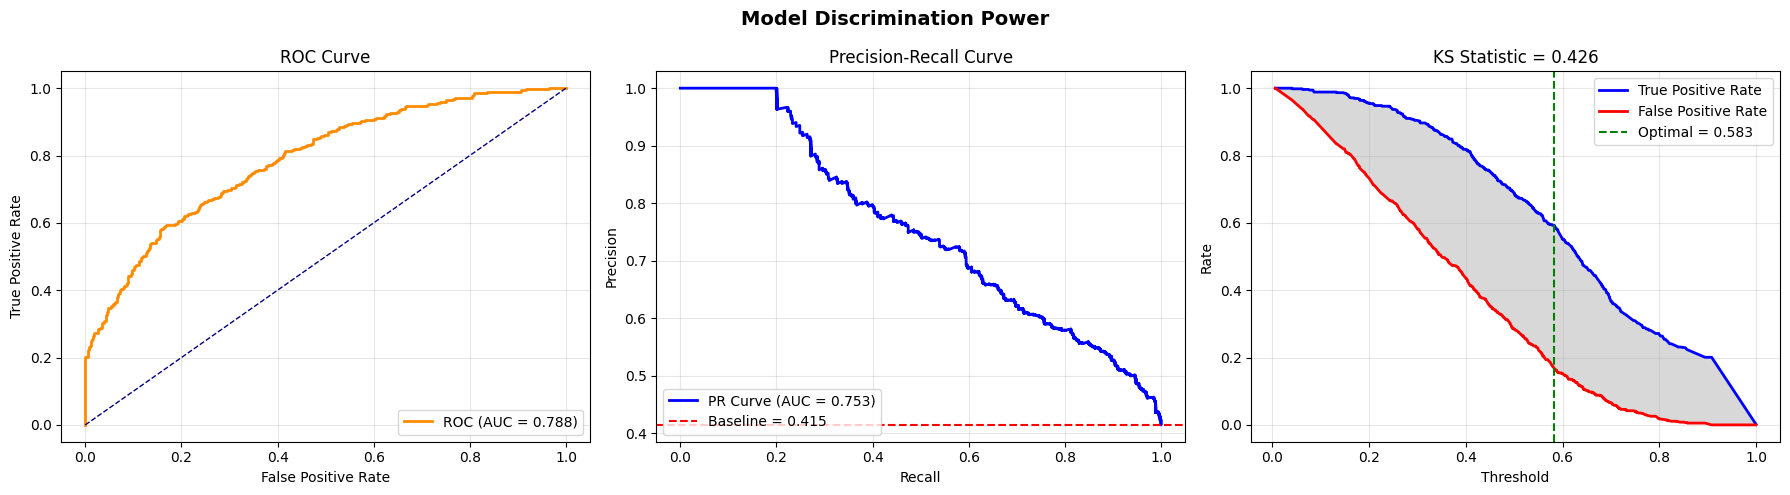

• ROC-AUC: 0.7876
• PR-AUC: 0.7532
• KS Statistic: 0.426 (GOOD discrimination)
• Optimal Threshold: 0.583

💼 STEP 2: BUSINESS IMPACT
----------------------------------------
Verification of decile assignment:
Decile 1 mean prob: 0.973
Decile 10 mean prob: 0.073


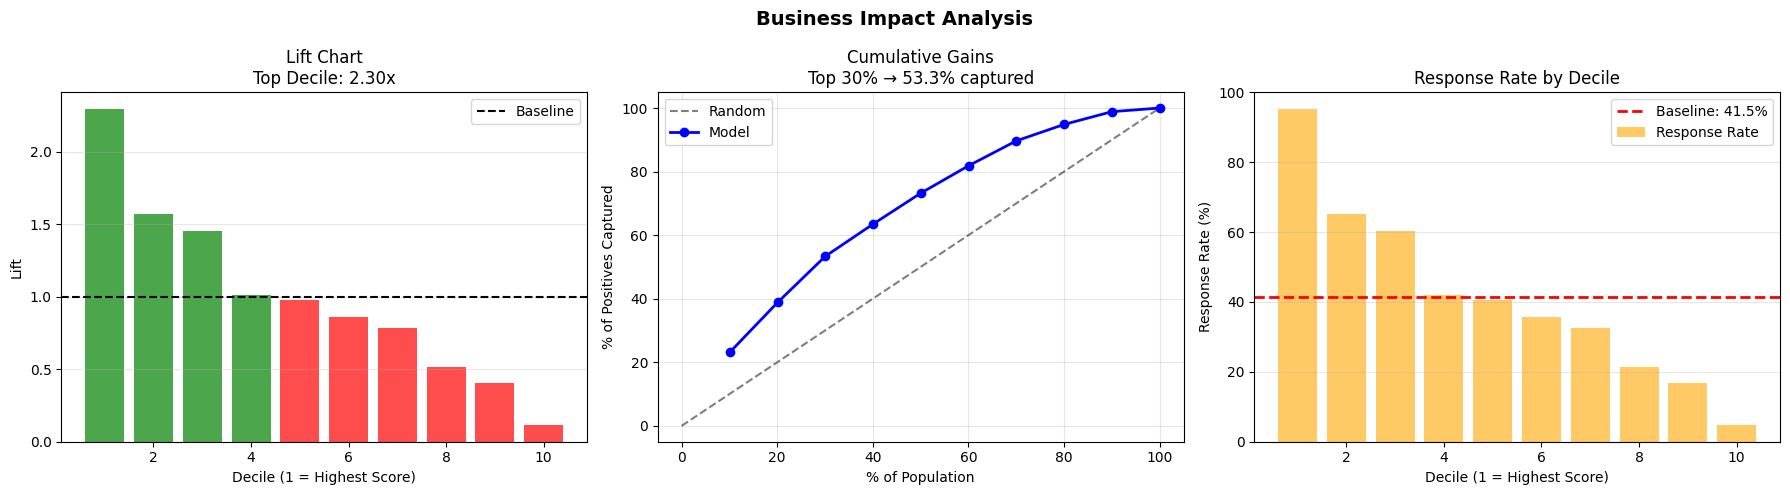

• Top Decile Lift: 0.11x
• Top 30% captures: 53.3% of positives
• Baseline response rate: 41.5%
• Top decile response: 95.3%

📈 STEP 4: CONFUSION MATRIX
----------------------------------------


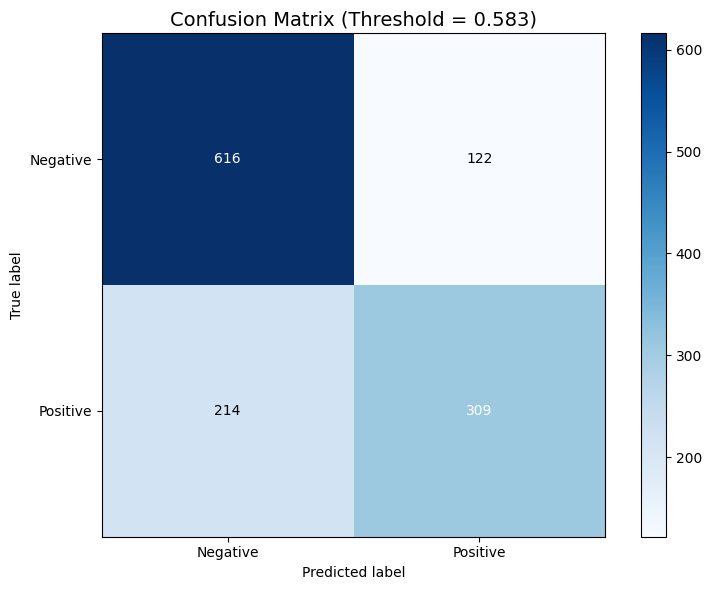

At threshold 0.583:
• Accuracy: 0.734
• Precision: 0.717
• Recall: 0.591
• F1-Score: 0.648
• True Positives: 309
• False Positives: 122
• True Negatives: 616
• False Negatives: 214

FINAL VALIDATION SUMMARY

✅ DISCRIMINATION POWER:
   KS Statistic: 0.426 (GOOD discrimination)

✅ BUSINESS VALUE:
   Efficiency: 0.11x better than random
   Coverage: Top 30% → 53.3% captured

✅ MODEL QUALITY:
   ROC-AUC: 0.7876 (Excellent if >0.8)
   PR-AUC: 0.7532 (Excellent if >0.7)

✅ OPERATIONAL METRICS:
   Optimal Threshold: 0.583
   Precision at threshold: 0.717
   Recall at threshold: 0.591

🔍 FEATURE IMPORTANCE - SUBPOPULATION MODEL

Top 20 Features:
                        feature  importance
176     quote_consistency_score    0.090613
165            is_quick_decider    0.051920
248                 value_score    0.031006
103         month_concentration    0.018421
92     primary_system_dominance    0.018225
5                   main_agency    0.017906
247      price_x_sophistication    0.017770
20

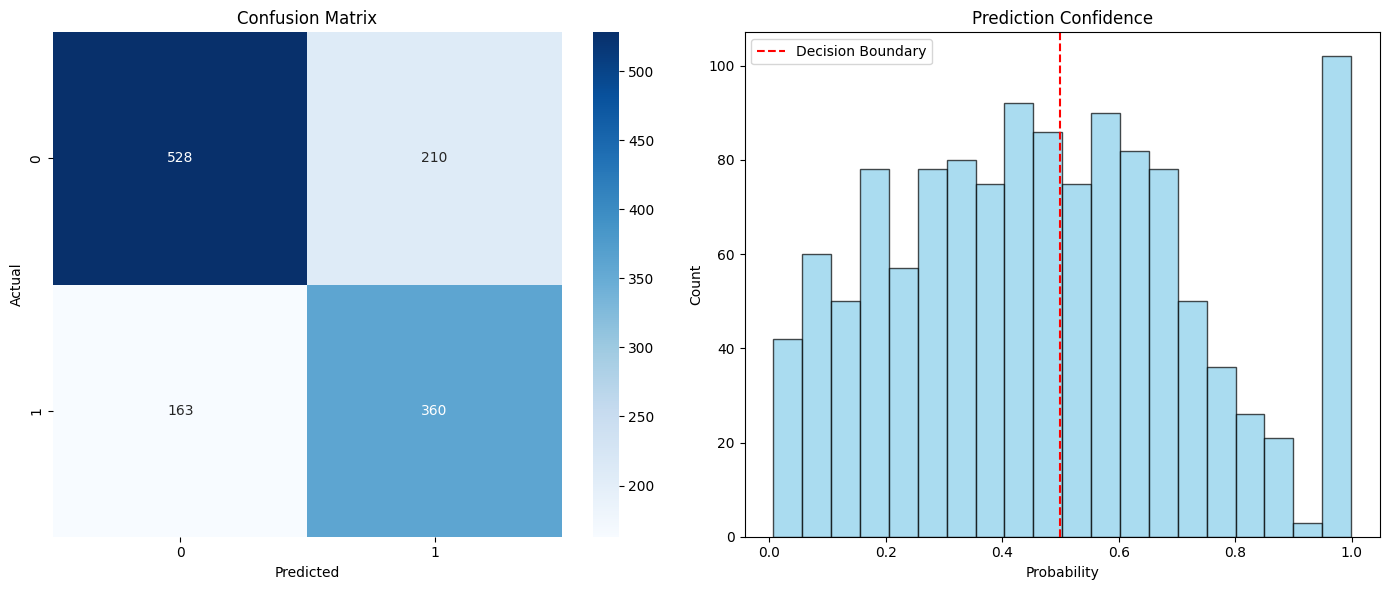

In [4]:
#with redirect_stdout(open('/dev/null', 'w')):
result = run_pipeline(df_quotes)

run_model_error_analysis(result['X_test'], result['y_test'], result['model'])